In [1]:
import zipfile
import glob

with zipfile.ZipFile("wykht8y7tg-1.zip", 'r') as zip_ref:
    zip_ref.extractall("battery_data")

# sorted() so file order stays identical every time you re-run this, on any machine
drive_cycle_files = sorted(glob.glob("battery_data/**/Drive Cycles/*.mat", recursive=True))
print(f"Found {len(drive_cycle_files)} drive cycle files")
for f in drive_cycle_files[:5]:
    print(f)

Found 50 drive cycle files
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_HWFET_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_LA92_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_UDDS_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_HWFET_UDDS_LA92_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_Pan18650PF.mat


In [2]:
train_file = [f for f in drive_cycle_files if "Cycle_2" in f][0]
print("Using:", train_file)

Using: battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-10-17_18.35 n10degC_Cycle_2_Pan18650PF.mat


In [3]:
from scipy.io import loadmat

mat = loadmat(train_file, squeeze_me=True, struct_as_record=False)
meas = mat["meas"]
print("Fields available:", meas._fieldnames)

Fields available: ['TimeStamp', 'Voltage', 'Current', 'Ah', 'Wh', 'Power', 'Battery_Temp_degC', 'Time', 'Chamber_Temp_degC']


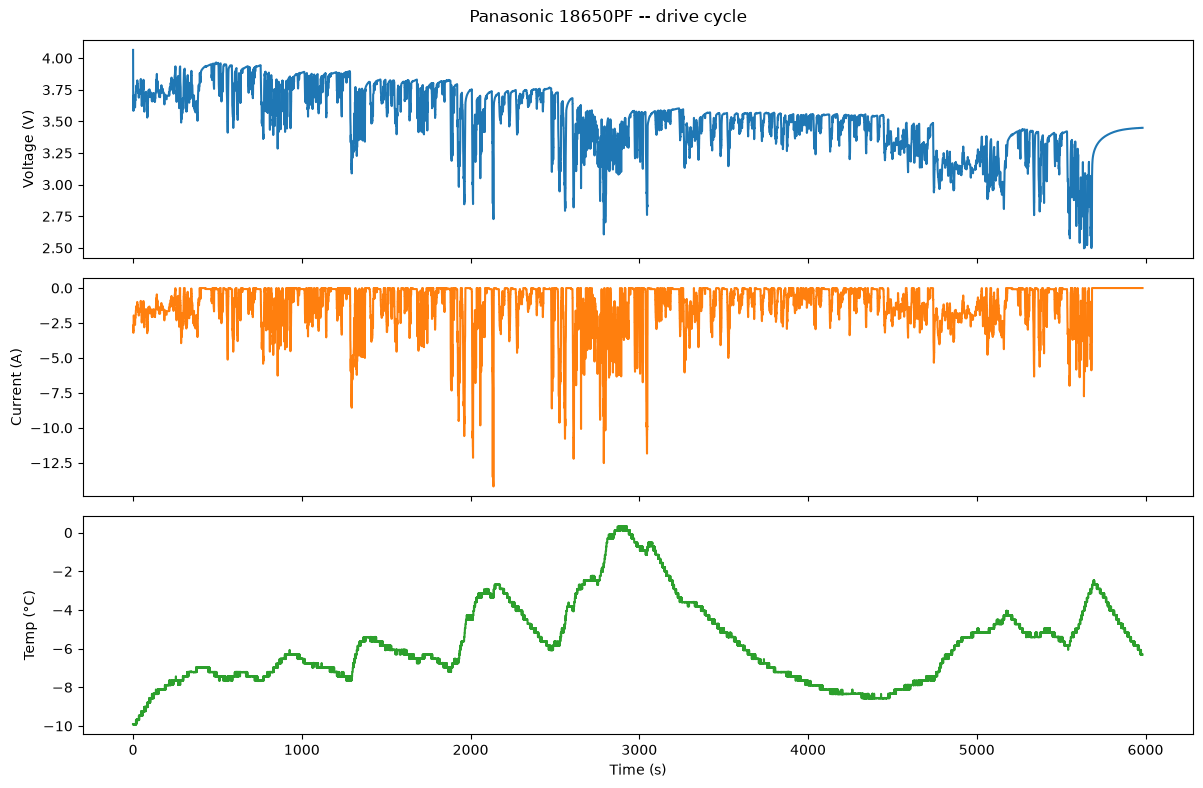

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "time_s": meas.Time,
    "voltage_V": meas.Voltage,
    "current_A": meas.Current,
    "temp_C": meas.Battery_Temp_degC,
    "ah": meas.Ah,
})

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df["time_s"], df["voltage_V"], color="tab:blue")
axes[0].set_ylabel("Voltage (V)")
axes[1].plot(df["time_s"], df["current_A"], color="tab:orange")
axes[1].set_ylabel("Current (A)")
axes[2].plot(df["time_s"], df["temp_C"], color="tab:green")
axes[2].set_ylabel("Temp (°C)")
axes[2].set_xlabel("Time (s)")
plt.suptitle("Panasonic 18650PF -- drive cycle")
plt.tight_layout()
plt.show()